In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import warnings 
warnings.filterwarnings("ignore") #ignore some matplotlib warnings

from triqs.plot.mpl_interface import plt, oplot, oplotr, oploti
plt.rcParams["figure.figsize"] = (8,5) # set default size for all figures

# Pole approximation of multi-orbital data with a discrete spectrum

In this example we consider a matrix-valued (multi-orbital) Matsubara function with a discrete spectrum: a sum of $K$ delta functions at random locations $p_k \in [-1, 1]$, with random rank-one (bath-site-like) residues,

$$F(\mathrm{i}\nu_n) = \sum_{k=1}^{K} \frac{v_k^{\phantom\dagger} v_k^\dagger}{\mathrm{i}\nu_n - p_k}, \qquad v_k \in \mathbb{C}^{n_{\mathrm{orb}}},$$

with the $p_k$ and $v_k$ drawn from a fixed random seed. Since the exact function is itself a sum of simple poles, the accuracy of any fit can be measured exactly. Note that the goal is *not* to recover the input poles: at a given target accuracy the fitting routines are free to use fewer — and differently placed — poles than the input, and for a compact representation that is exactly what one wants.

We briefly demonstrate the three main `adapol` functions with fixed, representative parameter choices — see the `semicircle` example for a more detailed exploration of the stopping criteria, the `nonlinear_optimization` switch, and the error metric. We then run a small experiment: using `approx_sop_tol`, we measure how many poles are actually required to reach a given accuracy as the number of orbitals grows.

In [2]:
import time

import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt

from adapol import approx_freq_aaa, approx_sop_fast, approx_sop_tol

np.set_printoptions(precision=3, suppress=True)

beta = 20.0

# Fermionic Matsubara sampling grid Z_n = i(2n+1)*pi/beta, symmetric about zero
nmax = 50
Z = 1j * (2 * np.arange(-nmax, nmax) + 1) * np.pi / beta


def make_random_model(n_orb, n_delta, seed_res):
    """Random discrete model: n_delta poles uniform on [-1,1] (fixed seed), rank-one
    residues v_k v_k^dag with complex Gaussian v_k, normalized so tr F ~ O(1)."""
    rng_poles = np.random.default_rng(0)
    rng_res = np.random.default_rng(seed_res)
    poles = np.sort(rng_poles.uniform(-1, 1, n_delta))
    v = (rng_res.standard_normal((n_delta, n_orb))
         + 1j * rng_res.standard_normal((n_delta, n_orb))) / np.sqrt(2 * n_delta)
    residues = np.einsum('ki,kj->kij', v, v.conj())
    return poles, residues


def eval_sop(z, poles, residues):
    """Evaluate the sum of simple poles sum_k residues[k] / (z - poles[k]) at points z."""
    C = 1.0 / (z[:, None] - poles[None, :])
    return np.einsum('zp,p...->z...', C, residues)


n_orb, n_delta = 4, 12
poles_ex, res_ex = make_random_model(n_orb, n_delta, seed_res=1)
F = eval_sop(Z, poles_ex, res_ex)

print(f"model: {n_delta} poles, {n_orb} orbitals, data shape {F.shape}")
print(f"pole locations: {poles_ex}")

model: 12 poles, 4 orbitals, data shape (100, 4, 4)
pole locations: [-0.995 -0.967 -0.918 -0.46   0.087  0.213  0.274  0.459  0.627  0.632
  0.826  0.87 ]


We plot a couple of matrix elements of the data.

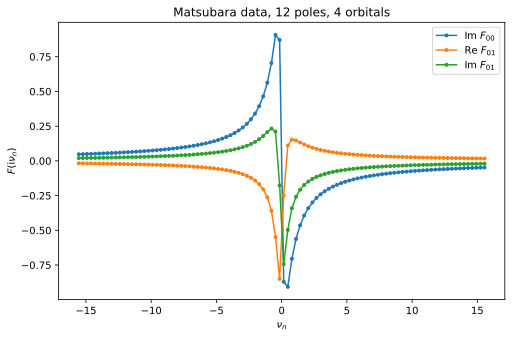

In [3]:
plt.plot(Z.imag, F[:, 0, 0].imag, 'o-', markersize=3, label=r'Im $F_{00}$')
plt.plot(Z.imag, F[:, 0, 1].real, 'o-', markersize=3, label=r'Re $F_{01}$')
plt.plot(Z.imag, F[:, 0, 1].imag, 'o-', markersize=3, label=r'Im $F_{01}$')
plt.xlabel(r'$\nu_n$')
plt.ylabel(r'$F(\mathrm{i}\nu_n)$')
plt.legend()
plt.title(f'Matsubara data, {n_delta} poles, {n_orb} orbitals')
plt.show()

We measure fit quality by the normalized imaginary-time $L^2$ error, with the Frobenius norm over the orbital indices,

$$\left\lVert F_{\mathrm{fit}} - F \right\rVert_{L^2(\tau)} = \left( \frac{1}{\beta}\int_0^\beta \sum_{ij} \left| \big(F_{\mathrm{fit}}\big)_{ij}(\tau) - F_{ij}(\tau) \right|^2 d\tau \right)^{1/2},$$

which is the same norm `approx_sop_fast` and `approx_sop_tol` report. Since the exact function is a known sum of poles, we can evaluate it in imaginary time analytically and compute the error by Gauss–Legendre quadrature (see the `semicircle` example):

In [4]:
def K_tau(tau, omega):
    """Imaginary-time kernel K(tau, omega) = -exp(-tau*omega) / (1 + exp(-beta*omega)),
    evaluated in a numerically stable way for both signs of omega."""
    K = np.empty((len(tau), len(omega)))
    p = omega > 0
    m = ~p
    t = tau[:, None]
    K[:, p] = -np.exp(-t * omega[p]) / (1 + np.exp(-beta * omega[p]))
    K[:, m] = -np.exp((beta - t) * omega[m]) / (1 + np.exp(beta * omega[m]))
    return K


x_gl, w_gl = np.polynomial.legendre.leggauss(200)
tau_q = 0.5 * beta * (x_gl + 1)
w_q = 0.5 * beta * w_gl

F_tau = np.einsum('tp,pij->tij', K_tau(tau_q, poles_ex), res_ex)


def l2tau_error(poles, residues):
    """Normalized Frobenius L2(tau) error of a sum of simple poles vs the exact model."""
    fit_tau = np.einsum('tp,p...->t...', K_tau(tau_q, poles), residues)
    d2 = np.abs(fit_tau - F_tau) ** 2
    return np.sqrt(np.sum(w_q * d2.reshape(len(tau_q), -1).sum(axis=1)) / beta)


print(f"||F||_L2(tau) = {np.sqrt(np.einsum('t,tij->', w_q, np.abs(F_tau)**2) / beta):.4f}")

||F||_L2(tau) = 0.3440


## Fitting the Matsubara data: approx_freq_aaa

`approx_freq_aaa` fits the raw frequency data $(F, Z)$; matrix-valued data of shape `(N, n_orb, n_orb)` is supported directly, and a single set of poles is found for all matrix elements at once. We try a few representative settings. At a moderate tolerance the data — generated by 12 poles — is fit with *fewer* poles: 9 suffice for $\sim 10^{-6}$ accuracy. A pole budget `max_n_poles` instead caps the cost directly. The fitted residue matrices come out numerically Hermitian.

In [5]:
for kwargs in [dict(aaa_tol=1e-4),
               dict(max_n_poles=8),
               dict(aaa_tol=1e-10)]:
    p, r, err = approx_freq_aaa(F, Z, **kwargs)
    opts = ', '.join(f'{k}={v}' for k, v in kwargs.items())
    print(f"{opts:20s} ->  {len(p):2d} poles,  error at samples = {err:.1e},  "
          f"L2(tau) error = {l2tau_error(p, r):.1e}")

aaa_tol=0.0001       ->   9 poles,  error at samples = 4.2e-06,  L2(tau) error = 1.5e-06
max_n_poles=8        ->   7 poles,  error at samples = 5.7e-04,  L2(tau) error = 1.3e-04
aaa_tol=1e-10        ->  13 poles,  error at samples = 1.1e-15,  L2(tau) error = 2.4e-16


## Compressing the exact expansion: approx_sop_fast

The two SOP routines take the exact poles and residues as input directly. `approx_sop_fast` makes a single AAA pass (with the residues refit in imaginary time), controlled by `aaa_tol` and/or `max_n_poles`; `nonlinear_optimization=True` additionally refines the pole locations, though here the AAA poles are already essentially optimal and it adds only cost:

In [6]:
for kwargs in [dict(aaa_tol=1e-4),
               dict(max_n_poles=8),
               dict(max_n_poles=8, nonlinear_optimization=True)]:
    t0 = time.perf_counter()
    p, r, err = approx_sop_fast(poles_ex, res_ex, beta, **kwargs)
    dt = (time.perf_counter() - t0) * 1e3
    opts = ', '.join(f'{k}={v}' for k, v in kwargs.items())
    print(f"{opts:45s} ->  {len(p):2d} poles,  L2(tau) error = {err:.1e},  t = {dt:5.1f} ms")

aaa_tol=0.0001                                ->   9 poles,  L2(tau) error = 1.5e-06,  t =   8.9 ms
max_n_poles=8                                 ->   7 poles,  L2(tau) error = 1.3e-04,  t =   5.3 ms
max_n_poles=8, nonlinear_optimization=True    ->   7 poles,  L2(tau) error = 1.3e-04,  t =   8.9 ms


## Compression to a prescribed accuracy: approx_sop_tol

`approx_sop_tol` finds the smallest expansion whose final $L^2(\tau)$ error is below `tol` — so the tolerance directly controls the pole count. Only near roundoff does the required count approach that of the input:

In [7]:
for tol in [1e-3, 1e-6, 1e-10]:
    p, r, err = approx_sop_tol(poles_ex, res_ex, tol=tol, beta=beta, verbose=False)
    print(f"tol = {tol:.0e}  ->  {len(p):2d} poles,  L2(tau) error = {err:.1e}")

tol = 1e-03  ->   7 poles,  L2(tau) error = 1.3e-04
tol = 1e-06  ->  11 poles,  L2(tau) error = 5.1e-09
tol = 1e-10  ->  13 poles,  L2(tau) error = 3.6e-16


The compressed poles are not simply a subset of the input poles — they are placed wherever the requested accuracy demands. At `tol = 1e-3`, seven poles reproduce the 12-pole function: the cluster of three input poles near $\omega \approx -0.95$ is replaced by a *single* pole carrying their combined spectral weight (residue trace $0.50 \approx 0.19 + 0.18 + 0.13$), the near-degenerate pair at $\omega \approx 0.63$ is likewise merged, and the remaining poles shift away from their input locations — yet the function is reproduced to the requested accuracy:

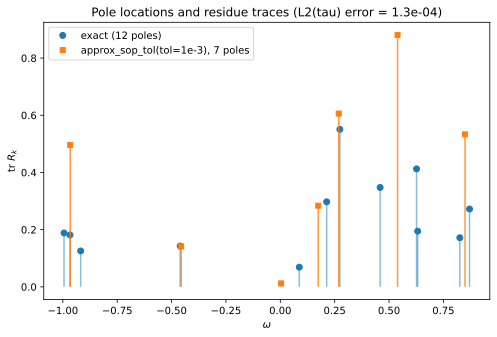

In [8]:
p7, r7, err7 = approx_sop_tol(poles_ex, res_ex, tol=1e-3, beta=beta, verbose=False)
idx = np.argsort(p7)
p7s, tr7 = p7[idx], np.einsum('kii->k', r7[idx]).real
tr_ex = np.einsum('kii->k', res_ex).real

plt.vlines(poles_ex, 0, tr_ex, color='C0', alpha=0.5)
plt.plot(poles_ex, tr_ex, 'C0o', label=f'exact ({n_delta} poles)')
plt.vlines(p7s, 0, tr7, color='C1', alpha=0.8)
plt.plot(p7s, tr7, 'C1s', markersize=5, label=f'approx_sop_tol(tol=1e-3), {len(p7s)} poles')
plt.xlabel(r'$\omega$')
plt.ylabel(r'tr $R_k$')
plt.legend()
plt.title(f'Pole locations and residue traces (L2(tau) error = {err7:.1e})')
plt.show()

## How does the required number of poles vary with the number of orbitals?

To test this, we fix $K = 40$ delta functions (same random locations throughout) and draw independent random residue vectors for increasing $n_{\mathrm{orb}}$, then ask `approx_sop_tol` for the minimal pole count at fixed tolerances.

For a single orbital, many of the 40 poles can be merged. As $n_{\mathrm{orb}}$ grows, the data contains more independent linear combinations of the poles and the required count increases — but it quickly *saturates*, far below 40. The saturation level is the numerical $\epsilon$-rank of the Matsubara kernel $1/(\mathrm{i}\nu_n - \omega)$ on $\omega \in [-1,1]$ (dashed lines, computed with the pivoted-QR construction from the `semicircle` example): a universal pole set of that size can represent *any* function with this spectral support to accuracy $\epsilon$, no matter how many orbitals. This is the concept underlying the discrete Lehmann representation [[1]](#references): in the limit of a large number of orbitals, the required pole count is set by the spectral support and the target accuracy — not by the number of orbitals (nor by the $n_{\mathrm{orb}}^2$ matrix elements, nor the 40 input poles).

tol = 1e-04:  n_orb = [1, 2, 3, 4, 6, 8, 12, 16, 20, 24]  ->  poles = [5, 7, 9, 9, 9, 9, 9, 11, 11, 11]
tol = 1e-06:  n_orb = [1, 2, 3, 4, 6, 8, 12, 16, 20, 24]  ->  poles = [7, 11, 11, 13, 13, 13, 13, 13, 13, 13]
kernel epsilon-ranks: {0.0001: 11, 1e-06: 13}


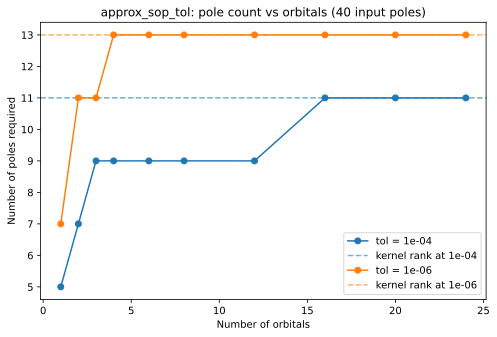

In [9]:
n_delta_sweep = 40
tols = [1e-4, 1e-6]
n_orbs = [1, 2, 3, 4, 6, 8, 12, 16, 20, 24]

counts = {}
for tol in tols:
    counts[tol] = []
    for no in n_orbs:
        poles_s, res_s = make_random_model(no, n_delta_sweep, seed_res=100 + no)
        p, r, err = approx_sop_tol(poles_s, res_s, tol=tol, beta=beta, verbose=False)
        counts[tol].append(len(p))
    print(f"tol = {tol:.0e}:  n_orb = {n_orbs}  ->  poles = {counts[tol]}")

# epsilon-rank of the continuum Matsubara kernel on [-1, 1] (cf. the semicircle example)
Z_dense = 1j * (2 * np.arange(-200, 200) + 1) * np.pi / beta
om_cand = np.linspace(-1, 1, 501)
_, R, _ = scipy.linalg.qr(1.0 / (Z_dense[:, None] - om_cand[None, :]),
                          mode='economic', pivoting=True)
diagR = np.abs(np.diag(R))
ranks = {tol: int(np.sum(diagR > tol * diagR[0])) for tol in tols}
print(f"kernel epsilon-ranks: {ranks}")

for i, tol in enumerate(tols):
    plt.plot(n_orbs, counts[tol], f'C{i}o-', label=f'tol = {tol:.0e}')
    plt.axhline(ranks[tol], color=f'C{i}', linestyle='--', alpha=0.6,
                label=f'kernel rank at {tol:.0e}')
plt.xlabel('Number of orbitals')
plt.ylabel('Number of poles required')
plt.legend()
plt.title(f'approx_sop_tol: pole count vs orbitals ({n_delta_sweep} input poles)')
plt.show()

## References

[1] J. Kaye, K. Chen, and O. Parcollet, [Discrete Lehmann representation of imaginary time Green's functions](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.105.235115), Phys. Rev. B **105**, 235115 (2022).